Repository GitHub :
Membre de l'équipe : Carla Molinié

Ce notebook va calculer et tracer l’ENMO (Euclidean Norm Minus One) intégré sur des epochs de 10s, 30s et 60s. Pour chaque epoch, deux types de graphiques sont générés.

Je tape cette commande dans Copilot : à  partir d'un fichier .csv avec des données brutes d'accéléromètres et organisé de cette façon : fichier contient 4 colonnes : t (en secondes), x, y, z (en g), comment extraire ces données pour Tracé de l’ENMO intégré sur une époque pour des époques variées, être en mesure de produire les graphiques suivants pour des longueurs d’époque de 10 s, 30 s et 60 s.
Etre vigilant : la première ligne du .csv est du texte inutile, la deuxième ligne on trouve t (pour le temps en secondes), x, y et z chacun est dansune colonne avec ces données dessous en colonne.


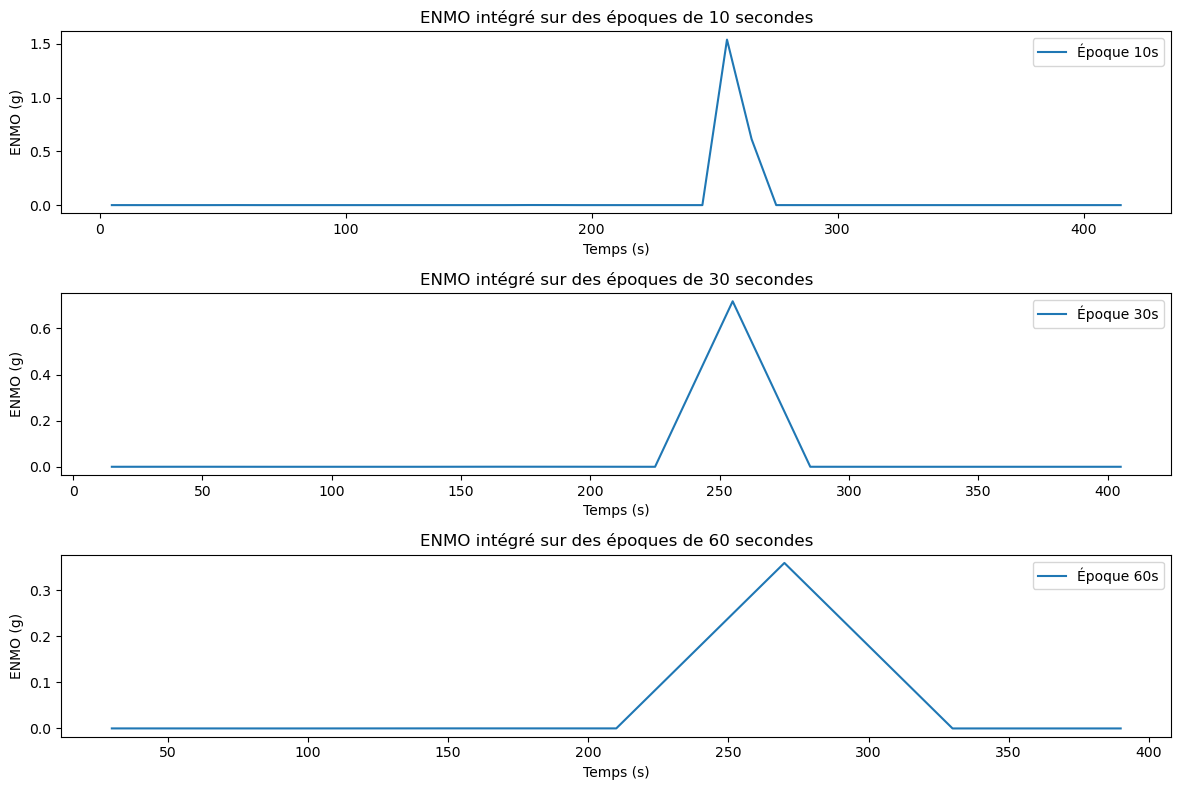

In [4]:
# Importer les bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger le fichier CSV en sautant la première ligne inutile
df = pd.read_csv('0_z.csv', skiprows=1)  # Adapter le nom du fichier si besoin

# Calculer l'ENMO (Euclidean Norm Minus One) pour chaque ligne
df['enmo'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2) - 1
df['enmo'] = df['enmo'].clip(lower=0)  # ENMO ne peut pas être négatif

# Fonction pour agréger l'ENMO sur des époques de durée variable
def aggregate_enmo(df, epoch_length):
    df = df.copy()
    df['epoch'] = (df['t'] // epoch_length).astype(int)
    enmo_epoch = df.groupby('epoch')['enmo'].mean()
    t_epoch = df.groupby('epoch')['t'].mean()
    return t_epoch, enmo_epoch

# Tracer l'ENMO pour différentes longueurs d'époque
epoch_lengths = [10, 30, 60]
plt.figure(figsize=(12, 8))
for i, epoch_length in enumerate(epoch_lengths, 1):
    t_epoch, enmo_epoch = aggregate_enmo(df, epoch_length)
    plt.subplot(3, 1, i)
    plt.plot(t_epoch, enmo_epoch, label=f'Époque {epoch_length}s')
    plt.xlabel('Temps (s)')
    plt.ylabel('ENMO (g)')
    plt.title(f'ENMO intégré sur des époques de {epoch_length} secondes')
    plt.legend()
    plt.tight_layout()
plt.show()

Ce code me fais que les graphiques ENMO en fonction du temps, je demande un autre code pour avoir le tracé de l'ENMO intégré : maintenant dans une autre cellule de code il faut également que tu me fasses un graphique integrated enmo et en abscisse ENMO over time

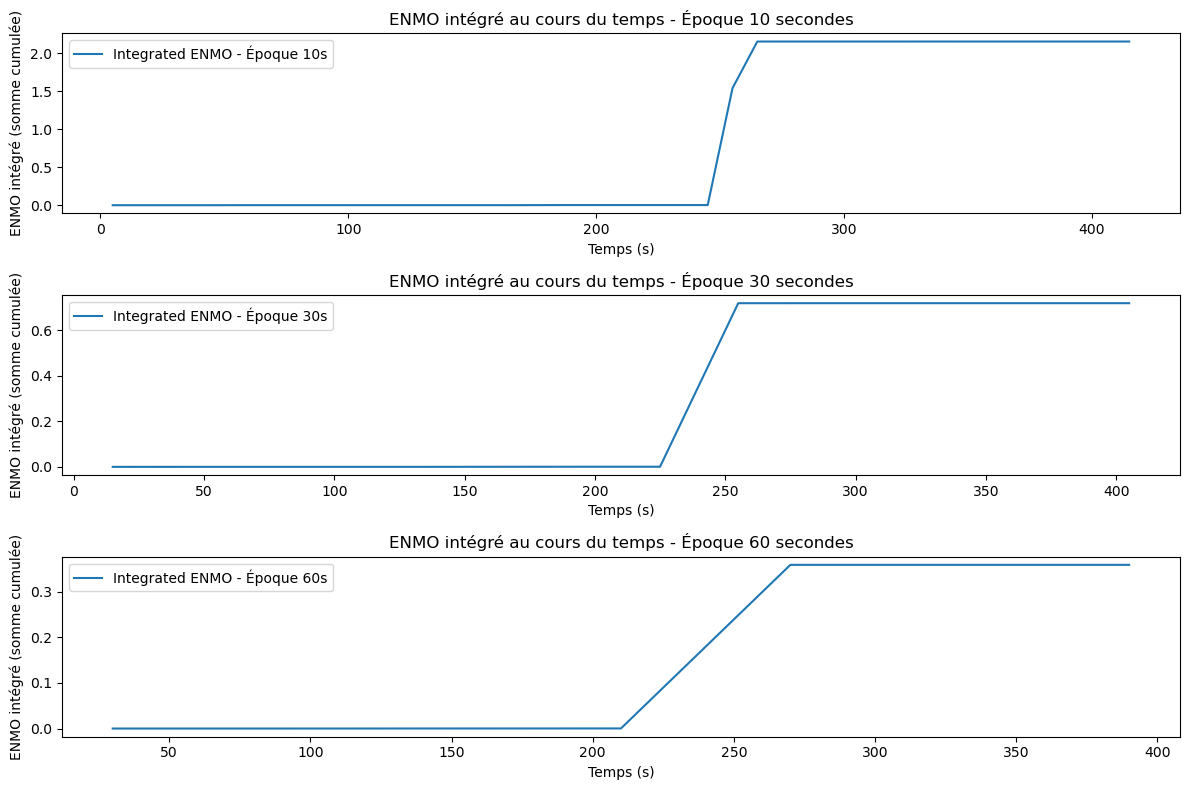

In [7]:
# Tracer l'ENMO intégré (cumulé) pour différentes longueurs d'époque (10s, 30s, 60s)
epoch_lengths = [10, 30, 60]
plt.figure(figsize=(12, 8))
for i, epoch_length in enumerate(epoch_lengths, 1):
    t_epoch, enmo_epoch = aggregate_enmo(df, epoch_length)
    integrated_enmo = enmo_epoch.cumsum()
    plt.subplot(3, 1, i)
    plt.plot(t_epoch, integrated_enmo, label=f'Integrated ENMO - Époque {epoch_length}s')
    plt.xlabel('Temps (s)')
    plt.ylabel('ENMO intégré (somme cumulée)')
    plt.title(f'ENMO intégré au cours du temps - Époque {epoch_length} secondes')
    plt.legend()
    plt.tight_layout()
plt.show()

Je trouve ce graphique un peu étrange il va falloir que je retravaille dessus.